# SLICES tipado: diseño, transformación y validación

Este notebook construye **SLICES tokenizer v1** como una capa léxica explícita sobre ChemBERTa. Documenta el **porqué**, el **cómo** y el **para qué** del tipado, transforma los splits ya congelados y repite la auditoría antes de cualquier entrenamiento.

El objetivo no es cambiar la estructura descrita por SLICES. El objetivo es que cada unidad de su gramática llegue al Transformer como una unidad semántica inequívoca.

## 0. Motivación

La auditoría anterior encontró cobertura de caracteres completa, pero tokenización semánticamente incorrecta:

- 2,036 secuencias SLICES y 131 tipos de tokens.
- Sólo 29 tipos eran una unidad para ChemBERTa; 102 se fragmentaban.
- No había `<unk>`, pero 91,983 apariciones contenían fragmentación.
- La secuencia crecía en promedio 2.70 veces y 143 casos superaban 512 tokens.
- Ninguno de los 27 vectores de traslación era una unidad.

Que no exista `<unk>` sólo significa que el tokenizador puede representar los **caracteres**. No significa que preserve la gramática. Por ejemplo, `ooo → o o o`, `10 → 1 0` y `Fe → F e`. Además, un dígito en SMILES suele representar cierre de anillo, mientras que en SLICES identifica un nodo del grafo cociente. Reutilizar el mismo token introduciría una ambigüedad semántica aunque no hubiera fragmentación.

Por eso tipamos las tres familias completas, no únicamente los tokens que ChemBERTa fragmentaba.

## Flujo del experimento

```text
split congelado por material_id
          │
          ▼
validar gramática SLICES
          │
          ▼
tipar <EL_x>, <N_x>, <T_xyz>
          │
          ▼
construir vocabulario sólo con train
          │
          ▼
extender tokenizer de ChemBERTa
          │
          ▼
re-auditar fragmentación y longitud
          │
          ▼
exportar datos y tokenizer v1
```

No se hace augmentation ni se entrena el modelo en este notebook. Primero se demuestra que una representación canónica entra completa y sin fragmentación.

In [2]:
from collections import Counter
from hashlib import sha256
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from pymatgen.core import Element
from transformers import AddedToken, AutoTokenizer

pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 120)

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'splits' / 'train.csv').exists():
            return candidate
    raise FileNotFoundError('No se encontró data/splits/train.csv.')

PROJECT_ROOT = find_project_root(Path.cwd())
SPLIT_DIR = PROJECT_ROOT / 'data' / 'splits'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'slices_tipado'
TOKENIZER_DIR = OUTPUT_DIR / 'chemberta_slices_tokenizer_v1'

MODEL_NAME = 'seyonec/ChemBERTa-zinc-base-v1'
MODEL_REVISION = '761d6a18cf99db371e0b43baf3e2d21b3e865a20'
CACHE_DIR = PROJECT_ROOT / '.cache' / 'huggingface'
SLICES_MARKER = '[SLICES]'
SPLIT_NAMES = ('train', 'val', 'test')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Proyecto: {PROJECT_ROOT}')
print(f'Splits: {SPLIT_DIR.relative_to(PROJECT_ROOT)}')
print(f'Salida: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}')

Proyecto: /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis
Splits: data/splits
Salida: data/slices_tipado


## 1. Respetar el split congelado

El tipado se aprende únicamente desde `train`. Validación y prueba se usan sólo para comprobar cobertura. Esto evita que decisiones del vocabulario dependan de los conjuntos de evaluación. La asociación `material_id → split` no se vuelve a sortear.

In [3]:
splits = {name: pd.read_csv(SPLIT_DIR / f'{name}.csv') for name in SPLIT_NAMES}

for name, frame in splits.items():
    required = {'material_id', 'nsites', 'slices_string'}
    missing = required.difference(frame.columns)
    if missing:
        raise KeyError(f'{name}: faltan columnas {sorted(missing)}')
    if frame[list(required)].isna().any().any():
        raise ValueError(f'{name}: hay valores nulos en columnas requeridas.')

for left, right in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
    assert set(splits[left]['material_id']).isdisjoint(splits[right]['material_id'])
    assert set(splits[left]['slices_string']).isdisjoint(splits[right]['slices_string'])

split_overview = pd.DataFrame([
    {
        'split': name,
        'filas': len(frame),
        'material_id_únicos': frame['material_id'].nunique(),
        'SLICES_únicos': frame['slices_string'].nunique(),
    }
    for name, frame in splits.items()
])
display(split_overview)

,split,filas,material_id_únicos,SLICES_únicos
0,train,1628,1628,1628
1,val,204,204,204
2,test,204,204,204


## 2. Gramática que vamos a preservar

Una secuencia de este dataset tiene dos regiones:

```text
ELEMENTOS...   i  j  xyz   i  j  xyz ...
────────────   └── arista ─┘ └── arista ─┘
```

- Los elementos enumeran los nodos del grafo cociente. Su posición define el identificador del nodo.
- Cada arista contiene dos índices enteros `i`, `j`.
- `xyz` es un vector de traslación periódica de tres componentes en `{-, o, +}`, equivalentes a `{-1, 0, +1}`.
- Una estructura puede no tener aristas explícitas; por ejemplo `Hg Hg Hg` es válida.

El parser siguiente no infiere ni corrige estructuras. Falla si la secuencia no satisface esta gramática, si un índice apunta fuera de la lista de nodos o si el número de elementos no coincide con `nsites`.

In [4]:
TRANSLATION_RE = re.compile(r'^[+o-]{3}$')

def parse_slices(value: str, expected_nsites: int | None = None) -> dict:
    tokens = str(value).split()
    if not tokens:
        raise ValueError('SLICES vacío.')

    edge_start = next((i for i, token in enumerate(tokens) if token.isdigit()), len(tokens))
    atoms = tokens[:edge_start]
    edge_tokens = tokens[edge_start:]

    if not atoms:
        raise ValueError('La secuencia no contiene nodos/elementos.')
    for symbol in atoms:
        try:
            Element(symbol)
        except ValueError as error:
            raise ValueError(f'Elemento inválido: {symbol!r}') from error

    if expected_nsites is not None and len(atoms) != int(expected_nsites):
        raise ValueError(f'{len(atoms)} elementos en SLICES, pero nsites={expected_nsites}.')
    if len(edge_tokens) % 3 != 0:
        raise ValueError('La región de aristas no es múltiplo de tres.')

    edges = []
    for position in range(0, len(edge_tokens), 3):
        source_token, target_token, translation = edge_tokens[position:position + 3]
        if not source_token.isdigit() or not target_token.isdigit():
            raise ValueError(f'Índices inválidos: {source_token!r}, {target_token!r}.')
        source, target = int(source_token), int(target_token)
        if source >= len(atoms) or target >= len(atoms):
            raise ValueError(f'Arista ({source}, {target}) fuera de {len(atoms)} nodos.')
        if not TRANSLATION_RE.fullmatch(translation):
            raise ValueError(f'Traslación inválida: {translation!r}.')
        edges.append((source, target, translation))

    return {'atoms': tuple(atoms), 'edges': tuple(edges)}

def serialize_slices(parsed: dict) -> str:
    tokens = list(parsed['atoms'])
    for source, target, translation in parsed['edges']:
        tokens.extend([str(source), str(target), translation])
    return ' '.join(tokens)

parsed_by_split = {}
grammar_rows = []
for split_name, frame in splits.items():
    parsed_records = []
    for row in frame.itertuples(index=False):
        parsed = parse_slices(row.slices_string, expected_nsites=row.nsites)
        normalized = ' '.join(str(row.slices_string).split())
        assert serialize_slices(parsed) == normalized
        parsed_records.append(parsed)
        grammar_rows.append({
            'split': split_name, 'material_id': row.material_id,
            'n_nodos': len(parsed['atoms']), 'n_aristas': len(parsed['edges']),
            'sin_aristas': len(parsed['edges']) == 0,
        })
    parsed_by_split[split_name] = parsed_records

grammar_audit = pd.DataFrame(grammar_rows)
display(grammar_audit.groupby('split').agg(
    secuencias=('material_id', 'size'), nodos_mín=('n_nodos', 'min'),
    nodos_mediana=('n_nodos', 'median'), nodos_máx=('n_nodos', 'max'),
    aristas_mín=('n_aristas', 'min'), aristas_mediana=('n_aristas', 'median'),
    aristas_máx=('n_aristas', 'max'), sin_aristas=('sin_aristas', 'sum'),
))
display(splits['train'].loc[grammar_audit.query("split == 'train' and sin_aristas").index[:3],
                            ['material_id', 'formula_pretty', 'nsites', 'slices_string']])

,secuencias,nodos_mín,nodos_mediana,nodos_máx,aristas_mín,aristas_mediana,aristas_máx,sin_aristas
split,,,,,,,,
test,204,2,12.0,20,2,24.0,96,0
train,1628,1,12.5,20,0,28.0,96,1
val,204,3,12.0,20,2,25.0,96,0


,material_id,formula_pretty,nsites,slices_string
1090,mp-2629196,Hg,3,Hg Hg Hg


## 3. Decisión de tipado

| Familia | Forma original | Forma tipada | Significado |
|---|---|---|---|
| Modo | — | `[SLICES]` | Cambia explícitamente del lenguaje molecular al lenguaje SLICES |
| Elemento | `Fe` | `<EL_Fe>` | Nodo cuyo atributo químico es hierro |
| Índice | `10` | `<N_10>` | Referencia al nodo 10 del grafo cociente |
| Traslación | `+oo` | `<T_+oo>` | Vector periódico `(+1, 0, 0)` |

Se tipan **todos** los elementos e índices, incluso aquellos que ChemBERTa ya reconocía. Esto evita una representación híbrida determinada accidentalmente por el vocabulario SMILES. La transformación es uno-a-uno y reversible; no cambia el orden de nodos ni aristas.

In [5]:
TYPED_ELEMENT_RE = re.compile(r'^<EL_([A-Z][a-z]?)>$')
TYPED_NODE_RE = re.compile(r'^<N_(\d+)>$')
TYPED_TRANSLATION_RE = re.compile(r'^<T_([+o-]{3})>$')

def type_parsed_slices(parsed: dict) -> str:
    tokens = [SLICES_MARKER]
    tokens.extend(f'<EL_{symbol}>' for symbol in parsed['atoms'])
    for source, target, translation in parsed['edges']:
        tokens.extend([f'<N_{source}>', f'<N_{target}>', f'<T_{translation}>'])
    return ' '.join(tokens)

def detype_slices(value: str) -> str:
    tokens = str(value).split()
    if not tokens or tokens[0] != SLICES_MARKER:
        raise ValueError(f'Falta el marcador inicial {SLICES_MARKER}.')
    content = tokens[1:]
    edge_start = next((i for i, token in enumerate(content) if TYPED_NODE_RE.fullmatch(token)), len(content))

    atoms = []
    for token in content[:edge_start]:
        match = TYPED_ELEMENT_RE.fullmatch(token)
        if not match:
            raise ValueError(f'Token de elemento tipado inválido: {token!r}.')
        atoms.append(match.group(1))

    edge_tokens = content[edge_start:]
    if len(edge_tokens) % 3 != 0:
        raise ValueError('La región tipada de aristas no es múltiplo de tres.')
    original_tokens = list(atoms)
    for position in range(0, len(edge_tokens), 3):
        source_match = TYPED_NODE_RE.fullmatch(edge_tokens[position])
        target_match = TYPED_NODE_RE.fullmatch(edge_tokens[position + 1])
        translation_match = TYPED_TRANSLATION_RE.fullmatch(edge_tokens[position + 2])
        if not source_match or not target_match or not translation_match:
            raise ValueError(f'Tripleta tipada inválida: {edge_tokens[position:position + 3]}.')
        original_tokens.extend([source_match.group(1), target_match.group(1), translation_match.group(1)])
    return ' '.join(original_tokens)

typed_splits = {}
for split_name, frame in splits.items():
    typed_frame = frame.copy()
    typed_frame['slices_typed'] = [type_parsed_slices(parsed) for parsed in parsed_by_split[split_name]]
    for original, typed in zip(typed_frame['slices_string'], typed_frame['slices_typed']):
        normalized_original = ' '.join(str(original).split())
        reconstructed = detype_slices(typed)
        assert reconstructed == normalized_original
        parse_slices(reconstructed)
    typed_splits[split_name] = typed_frame

example = typed_splits['train'].iloc[0]
print('Original:')
print(example['slices_string'])
print('\nTipado:')
print(example['slices_typed'])
print('\nRound trip exacto:', detype_slices(example['slices_typed']) == example['slices_string'])

Original:
Zr Zr Zr Zr Se Se N N N N 0 7 -oo 0 7 o+o 0 7 ooo 0 6 ooo 0 5 o+o 0 5 ++o 0 5 ooo 1 6 +oo 1 6 o-o 1 6 ooo 1 7 ooo 1 4 +oo 1 4 ooo 1 4 ++o 2 9 o-o 2 9 +oo 2 9 ooo 2 8 oo- 2 4 +oo 2 4 ooo 2 4 ++o 3 8 -oo 3 8 o+o 3 8 ooo 3 9 oo+ 3 5 o+o 3 5 ++o 3 5 ooo

Tipado:
[SLICES] <EL_Zr> <EL_Zr> <EL_Zr> <EL_Zr> <EL_Se> <EL_Se> <EL_N> <EL_N> <EL_N> <EL_N> <N_0> <N_7> <T_-oo> <N_0> <N_7> <T_o+o> <N_0> <N_7> <T_ooo> <N_0> <N_6> <T_ooo> <N_0> <N_5> <T_o+o> <N_0> <N_5> <T_++o> <N_0> <N_5> <T_ooo> <N_1> <N_6> <T_+oo> <N_1> <N_6> <T_o-o> <N_1> <N_6> <T_ooo> <N_1> <N_7> <T_ooo> <N_1> <N_4> <T_+oo> <N_1> <N_4> <T_ooo> <N_1> <N_4> <T_++o> <N_2> <N_9> <T_o-o> <N_2> <N_9> <T_+oo> <N_2> <N_9> <T_ooo> <N_2> <N_8> <T_oo-> <N_2> <N_4> <T_+oo> <N_2> <N_4> <T_ooo> <N_2> <N_4> <T_++o> <N_3> <N_8> <T_-oo> <N_3> <N_8> <T_o+o> <N_3> <N_8> <T_ooo> <N_3> <N_9> <T_oo+> <N_3> <N_5> <T_o+o> <N_3> <N_5> <T_++o> <N_3> <N_5> <T_ooo>

Round trip exacto: True


## 4. Construir el vocabulario desde `train`

El vocabulario se deriva de la partición de entrenamiento. Después se comprueba que `val` y `test` no contienen familias nuevas. Cada traslación se documenta también como vector numérico.

In [6]:
def family_counters(parsed_records: list[dict]) -> dict[str, Counter]:
    counters = {'elemento': Counter(), 'nodo': Counter(), 'traslación': Counter()}
    for parsed in parsed_records:
        counters['elemento'].update(parsed['atoms'])
        for source, target, translation in parsed['edges']:
            counters['nodo'].update([str(source), str(target)])
            counters['traslación'][translation] += 1
    return counters

counters_by_split = {
    name: family_counters(parsed_by_split[name]) for name in SPLIT_NAMES
}
train_types = {family: set(counter) for family, counter in counters_by_split['train'].items()}

oov_rows = []
for split_name in ('val', 'test'):
    for family, counter in counters_by_split[split_name].items():
        missing = sorted(set(counter).difference(train_types[family]))
        oov_rows.append({
            'split': split_name, 'familia': family,
            'tipos_observados': len(counter), 'fuera_de_train': len(missing),
            'tokens_fuera_de_train': ', '.join(missing),
        })
oov_table = pd.DataFrame(oov_rows)
display(oov_table)
if oov_table['fuera_de_train'].sum() != 0:
    raise ValueError('Val/test contienen tokens que no están presentes en train.')

elements = sorted(train_types['elemento'], key=lambda symbol: Element(symbol).Z)
nodes = sorted(train_types['nodo'], key=int)
translation_value = {'-': -1, 'o': 0, '+': 1}
translations = sorted(
    train_types['traslación'],
    key=lambda token: tuple(translation_value[component] for component in token),
)

vocabulary_rows = [{
    'familia': 'marcador', 'token_original': '', 'token_tipado': SLICES_MARKER,
    'significado': 'inicio de una secuencia en lenguaje SLICES',
    'train_apariciones': len(splits['train']), 'val_apariciones': len(splits['val']),
    'test_apariciones': len(splits['test']),
}]

for symbol in elements:
    element = Element(symbol)
    vocabulary_rows.append({
        'familia': 'elemento', 'token_original': symbol, 'token_tipado': f'<EL_{symbol}>',
        'significado': f'elemento {symbol}; número atómico {element.Z}',
        **{f'{name}_apariciones': counters_by_split[name]['elemento'][symbol] for name in SPLIT_NAMES},
    })
for node in nodes:
    vocabulary_rows.append({
        'familia': 'nodo', 'token_original': node, 'token_tipado': f'<N_{node}>',
        'significado': f'identificador del nodo {node} en el grafo cociente',
        **{f'{name}_apariciones': counters_by_split[name]['nodo'][node] for name in SPLIT_NAMES},
    })
for translation in translations:
    vector = tuple(translation_value[component] for component in translation)
    vocabulary_rows.append({
        'familia': 'traslación', 'token_original': translation,
        'token_tipado': f'<T_{translation}>', 'significado': f'vector periódico {vector}',
        **{f'{name}_apariciones': counters_by_split[name]['traslación'][translation] for name in SPLIT_NAMES},
    })

vocabulary_table = pd.DataFrame(vocabulary_rows)
family_summary = (vocabulary_table.groupby('familia', sort=False)
                  .agg(tipos=('token_tipado', 'size'),
                       train_apariciones=('train_apariciones', 'sum'),
                       val_apariciones=('val_apariciones', 'sum'),
                       test_apariciones=('test_apariciones', 'sum'))
                  .reset_index())
display(family_summary)
display(vocabulary_table)
assert len(elements) == 84
assert len(nodes) == 20
assert len(translations) == 27
assert len(vocabulary_table) == 132

,split,familia,tipos_observados,fuera_de_train,tokens_fuera_de_train
0,val,elemento,76,0,
1,val,nodo,20,0,
2,val,traslación,26,0,
3,test,elemento,74,0,
4,test,nodo,20,0,
5,test,traslación,26,0,


,familia,tipos,train_apariciones,val_apariciones,test_apariciones
0,marcador,1,1628,204,204
1,elemento,84,20199,2383,2379
2,nodo,20,95222,11550,11310
3,traslación,27,47611,5775,5655


,familia,token_original,token_tipado,significado,train_apariciones,val_apariciones,test_apariciones
0,marcador,,[SLICES],inicio de una secuencia en lenguaje SLICES,1628,204,204
1,elemento,H,<EL_H>,elemento H; número atómico 1,99,15,12
2,elemento,Li,<EL_Li>,elemento Li; número atómico 3,553,70,44
3,elemento,Be,<EL_Be>,elemento Be; número atómico 4,21,0,0
4,elemento,B,<EL_B>,elemento B; número atómico 5,39,9,2
...,...,...,...,...,...,...,...
127,traslación,+oo,<T_+oo>,"vector periódico (1, 0, 0)",3446,437,392
128,traslación,+o+,<T_+o+>,"vector periódico (1, 0, 1)",350,47,41
129,traslación,++-,<T_++->,"vector periódico (1, 1, -1)",32,2,5
130,traslación,++o,<T_++o>,"vector periódico (1, 1, 0)",640,95,71


## 5. Extender ChemBERTa sin entrenar todavía

Se agregan 132 unidades: 84 elementos, 20 nodos, 27 traslaciones y `[SLICES]`. Los tokens regulares usan `lstrip=True` para consumir el espacio anterior como parte de la misma unidad, evitando el token separador `Ġ` observado en la auditoría original.

Esto **sólo extiende el tokenizer**. Todavía no crea embeddings útiles. En el modelo será necesario ejecutar `resize_token_embeddings` e inicializar los elementos a partir del conocimiento químico de ChemBERTa; nodos y traslaciones requerirán una estrategia distinta.

In [18]:
base_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME, revision=MODEL_REVISION, cache_dir=CACHE_DIR
)
extended_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME, revision=MODEL_REVISION, cache_dir=CACHE_DIR
)

base_size = len(extended_tokenizer)
marker_added = extended_tokenizer.add_special_tokens({
    'additional_special_tokens': [
        AddedToken(SLICES_MARKER, lstrip=False, rstrip=False, normalized=False, special=True)
    ]
})
regular_typed_tokens = vocabulary_table.loc[
    vocabulary_table['familia'] != 'marcador', 'token_tipado'
].tolist()
regular_added = extended_tokenizer.add_tokens([
    AddedToken(token, lstrip=True, rstrip=False, normalized=False, special=False)
    for token in regular_typed_tokens
])

vocabulary_table['token_id'] = vocabulary_table['token_tipado'].map(
    extended_tokenizer.convert_tokens_to_ids
)
vocabulary_table['piezas_modelo'] = vocabulary_table['token_tipado'].map(
    lambda token: len(extended_tokenizer.encode(token, add_special_tokens=False))
)

tokenizer_growth = pd.DataFrame({
    'métrica': ['vocabulario base', 'marcadores añadidos', 'tokens tipados añadidos', 'vocabulario final'],
    'valor': [base_size, marker_added, regular_added, len(extended_tokenizer)],
})
display(tokenizer_growth)
assert marker_added + regular_added == len(vocabulary_table)
assert vocabulary_table['token_id'].nunique() == len(vocabulary_table)
assert vocabulary_table['piezas_modelo'].eq(1).all()

sample_typed = typed_splits['train'].iloc[100]['slices_typed']
print(extended_tokenizer.tokenize(sample_typed)[:25])

,métrica,valor
0,vocabulario base,767
1,marcadores añadidos,1
2,tokens tipados añadidos,131
3,vocabulario final,899


['[SLICES]', ' <EL_Si>', ' <EL_C>', ' <EL_C>', ' <EL_N>', ' <EL_N>', ' <EL_N>', ' <EL_N>', ' <EL_N>', ' <EL_N>', ' <EL_F>', ' <EL_F>', ' <EL_F>', ' <EL_F>', ' <EL_F>', ' <EL_F>', ' <N_0>', ' <N_9>', ' <T_oo+>', ' <N_0>', ' <N_10>', ' <T_ooo>', ' <N_0>', ' <N_12>', ' <T_ooo>']


## 6. Re-audit obligatorio

Comparamos la tokenización original con la representación tipada. Para el tipado, cada token léxico debe producir exactamente un ID del tokenizer extendido. La longitud con especiales incluye `<s>` y `</s>`; `[SLICES]` ya forma parte del contenido.

In [8]:
sequence_audit_rows = []
special_count = extended_tokenizer.num_special_tokens_to_add(pair=False)
max_length = int(extended_tokenizer.model_max_length)

for split_name in SPLIT_NAMES:
    frame = typed_splits[split_name]
    for row in frame.itertuples(index=False):
        original_lexical = len(row.slices_string.split())
        typed_lexical = len(row.slices_typed.split())
        original_ids = base_tokenizer.encode(row.slices_string, add_special_tokens=False)
        typed_ids = extended_tokenizer.encode(row.slices_typed, add_special_tokens=False)
        sequence_audit_rows.append({
            'split': split_name, 'material_id': row.material_id,
            'tokens_slices_originales': original_lexical,
            'tokens_chemberta_original': len(original_ids),
            'tokens_slices_tipados': typed_lexical,
            'tokens_tokenizer_extendido': len(typed_ids),
            'factor_original': len(original_ids) / original_lexical,
            'factor_tipado_sobre_original': len(typed_ids) / original_lexical,
            'unk_original': sum(token_id == base_tokenizer.unk_token_id for token_id in original_ids),
            'unk_tipado': sum(token_id == extended_tokenizer.unk_token_id for token_id in typed_ids),
            'fragmentación_tipado': len(typed_ids) - typed_lexical,
            'longitud_tipado_con_especiales': len(typed_ids) + special_count,
            'excede_512_original': len(original_ids) + base_tokenizer.num_special_tokens_to_add(False) > max_length,
            'excede_512_tipado': len(typed_ids) + special_count > max_length,
        })

sequence_audit = pd.DataFrame(sequence_audit_rows)
assert sequence_audit['fragmentación_tipado'].eq(0).all()
assert sequence_audit['unk_tipado'].eq(0).all()

comparison = pd.DataFrame({
    'métrica': [
        'tipos fragmentados', 'traslaciones fragmentadas', 'elementos fragmentados',
        'índices fragmentados', '<unk> totales', 'factor medio de expansión',
        'secuencias >512', 'longitud máxima con especiales',
    ],
    'antes': [
        102, 27, 67, 8, int(sequence_audit['unk_original'].sum()),
        sequence_audit['factor_original'].mean(),
        int(sequence_audit['excede_512_original'].sum()),
        int((sequence_audit['tokens_chemberta_original'] + base_tokenizer.num_special_tokens_to_add(False)).max()),
    ],
    'después': [
        int((vocabulary_table['piezas_modelo'] != 1).sum()), 0, 0, 0,
        int(sequence_audit['unk_tipado'].sum()),
        sequence_audit['factor_tipado_sobre_original'].mean(),
        int(sequence_audit['excede_512_tipado'].sum()),
        int(sequence_audit['longitud_tipado_con_especiales'].max()),
    ],
    'objetivo': ['0', '0/27', '0', '0', '0', '≈1×', 'reducir drásticamente', '<=512'],
})
display(comparison)
display(sequence_audit.sort_values('longitud_tipado_con_especiales', ascending=False).head(15))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (555 > 512). Running this sequence through the model will result in indexing errors


,métrica,antes,después,objetivo
0,tipos fragmentados,102.000000,0.000000,0
1,traslaciones fragmentadas,27.000000,0.000000,0/27
2,elementos fragmentados,67.000000,0.000000,0
3,índices fragmentados,8.000000,0.000000,0
4,<unk> totales,0.000000,0.000000,0
5,factor medio de expansión,2.703044,1.015923,≈1×
6,secuencias >512,143.000000,0.000000,reducir drásticamente
7,longitud máxima con especiales,899.000000,311.000000,<=512


,split,material_id,tokens_slices_originales,tokens_chemberta_original,tokens_slices_tipados,tokens_tokenizer_extendido,factor_original,factor_tipado_sobre_original,unk_original,unk_tipado,fragmentación_tipado,longitud_tipado_con_especiales,excede_512_original,excede_512_tipado
1888,test,mp-1105955,308,897,309,309,2.912338,1.003247,0,0,0,311,True,False
817,train,mp-17926,308,897,309,309,2.912338,1.003247,0,0,0,311,True,False
2032,test,mp-1188599,308,893,309,309,2.899351,1.003247,0,0,0,311,True,False
630,train,mp-1210067,308,897,309,309,2.912338,1.003247,0,0,0,311,True,False
1342,train,mp-1105333,308,893,309,309,2.899351,1.003247,0,0,0,311,True,False
977,train,mp-1189310,308,897,309,309,2.912338,1.003247,0,0,0,311,True,False
1825,val,mp-1189617,308,897,309,309,2.912338,1.003247,0,0,0,311,True,False
654,train,mp-1105252,308,893,309,309,2.899351,1.003247,0,0,0,311,True,False
1951,test,mp-4473,308,891,309,309,2.892857,1.003247,0,0,0,311,True,False
955,train,mp-1105400,308,893,309,309,2.899351,1.003247,0,0,0,311,True,False


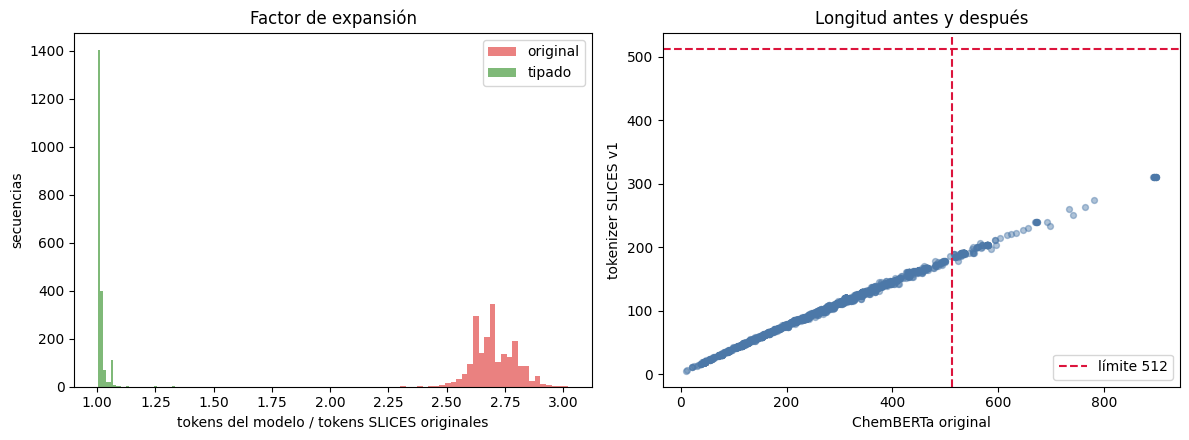

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(sequence_audit['factor_original'], bins=30, alpha=0.75, label='original', color='#E45756')
axes[0].hist(sequence_audit['factor_tipado_sobre_original'], bins=30, alpha=0.75, label='tipado', color='#54A24B')
axes[0].set(title='Factor de expansión', xlabel='tokens del modelo / tokens SLICES originales', ylabel='secuencias')
axes[0].legend()

original_lengths = sequence_audit['tokens_chemberta_original'] + base_tokenizer.num_special_tokens_to_add(False)
typed_lengths = sequence_audit['longitud_tipado_con_especiales']
axes[1].scatter(original_lengths, typed_lengths, alpha=0.45, s=18, color='#4C78A8')
axes[1].axvline(max_length, color='crimson', linestyle='--', label=f'límite {max_length}')
axes[1].axhline(max_length, color='crimson', linestyle='--')
axes[1].set(title='Longitud antes y después', xlabel='ChemBERTa original', ylabel='tokenizer SLICES v1')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Exportar representación, vocabulario y tokenizer

Los CSV tipados conservan todas las columnas originales y añaden `slices_typed`. El tokenizer guardado contiene la extensión léxica, pero **no contiene pesos del modelo ni embeddings entrenados**. El JSON de auditoría fija la revisión de ChemBERTa, las huellas de los splits y las métricas antes/después.

In [10]:
typed_paths = {}
for split_name, frame in typed_splits.items():
    path = OUTPUT_DIR / f'{split_name}_typed.csv'
    frame.to_csv(path, index=False)
    typed_paths[split_name] = path

VOCABULARY_PATH = OUTPUT_DIR / 'typed_vocabulary.csv'
SEQUENCE_AUDIT_PATH = OUTPUT_DIR / 'typing_sequence_audit.csv'
AUDIT_PATH = OUTPUT_DIR / 'typing_audit.json'
vocabulary_table.to_csv(VOCABULARY_PATH, index=False)
sequence_audit.to_csv(SEQUENCE_AUDIT_PATH, index=False)
extended_tokenizer.save_pretrained(TOKENIZER_DIR)

audit = {
    'schema_version': 'SLICES-typed-v1',
    'base_tokenizer': {'name': MODEL_NAME, 'revision': MODEL_REVISION, 'size': base_size},
    'extended_tokenizer_size': len(extended_tokenizer),
    'slices_marker': SLICES_MARKER,
    'vocabulary': {
        'total_added': len(vocabulary_table), 'elements': len(elements),
        'nodes': len(nodes), 'translations': len(translations),
    },
    'split_sources': {
        name: {
            'path': str((SPLIT_DIR / f'{name}.csv').relative_to(PROJECT_ROOT)),
            'sha256': sha256((SPLIT_DIR / f'{name}.csv').read_bytes()).hexdigest(),
            'rows': len(splits[name]),
        }
        for name in SPLIT_NAMES
    },
    'validation': {
        'grammar_errors': 0, 'round_trip_errors': 0,
        'val_test_types_outside_train': int(oov_table['fuera_de_train'].sum()),
        'typed_fragmentation': int(sequence_audit['fragmentación_tipado'].sum()),
        'typed_unknown_tokens': int(sequence_audit['unk_tipado'].sum()),
    },
    'lengths': {
        'original_mean_expansion': float(sequence_audit['factor_original'].mean()),
        'typed_mean_expansion_over_original': float(sequence_audit['factor_tipado_sobre_original'].mean()),
        'original_sequences_over_512': int(sequence_audit['excede_512_original'].sum()),
        'typed_sequences_over_512': int(sequence_audit['excede_512_tipado'].sum()),
        'typed_max_with_special_tokens': int(sequence_audit['longitud_tipado_con_especiales'].max()),
    },
}
AUDIT_PATH.write_text(json.dumps(audit, indent=2, ensure_ascii=False) + '\n', encoding='utf-8')

for split_name, path in typed_paths.items():
    print(f'{path.relative_to(PROJECT_ROOT)}: {len(typed_splits[split_name]):,} filas')
print(VOCABULARY_PATH.relative_to(PROJECT_ROOT))
print(SEQUENCE_AUDIT_PATH.relative_to(PROJECT_ROOT))
print(AUDIT_PATH.relative_to(PROJECT_ROOT))
print(TOKENIZER_DIR.relative_to(PROJECT_ROOT))

data/slices_tipado/train_typed.csv: 1,628 filas
data/slices_tipado/val_typed.csv: 204 filas
data/slices_tipado/test_typed.csv: 204 filas
data/slices_tipado/typed_vocabulary.csv
data/slices_tipado/typing_sequence_audit.csv
data/slices_tipado/typing_audit.json
data/slices_tipado/chemberta_slices_tokenizer_v1


## 8. Qué resuelve y qué no resuelve este notebook

### Resuelve

- Desambigua elementos, índices y traslaciones respecto del lenguaje SMILES.
- Elimina la fragmentación de las unidades SLICES observadas.
- Reduce la longitud y evita truncar cristales del dataset actual.
- Conserva una transformación reversible y auditable.
- Mantiene intacto el split congelado.

### Todavía no resuelve

- Los 132 tokens nuevos aún no tienen embeddings con significado aprendido.
- El orden de una SLICES canónica todavía puede introducir sensibilidad de serialización.
- No se ha hecho augmentation ni structural MLM.
- No se ha demostrado todavía mejora en una propiedad downstream.

### Siguiente paso

1. Cargar ChemBERTa y ejecutar `resize_token_embeddings(len(tokenizer))`.
2. Inicializar `<EL_x>` desde la representación química disponible para cada elemento.
3. Diseñar inicialización para `<N_x>` y `<T_xyz>`.
4. Congelar inicialmente el encoder y entrenar los embeddings nuevos.
5. Sólo después evaluar augmentation, structural MLM y gradual unfreezing.